In [8]:
import pandas as pd
import numpy as np

In [9]:
!pip install openpyxl

In [10]:
df=pd.read_csv("Dataset1.csv")

In [11]:
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,00:00:00,06:00:00,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,08:08:00,08:10:00,199
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,09:19:00,09:21:00,312
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,12:38:00,12:40:00,577


In [12]:
# Task 1:1
rows = df.shape[0]
cols = df.shape[1]
print(f"Total Records (Rows): {rows}")
print(f"Total Attributes (Columns): {cols}")
df.head()

Total Records (Rows): 186074
Total Attributes (Columns): 12


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [13]:
# Task 1.2: List all trains with their starting and ending stations
start_stations = df[df['SN'] == 1][['Train_No', 'Station_Name']]
start_stations.columns = ['Train_No', 'Starting_Station']
end_stations_idx = df.groupby('Train_No')['SN'].idxmax()
end_stations = df.loc[end_stations_idx, ['Train_No', 'Station_Name']]
end_stations.columns = ['Train_No', 'Ending_Station']
train_routes = pd.merge(start_stations, end_stations, on='Train_No')
print("--- List of Trains with Start and End Stations ---")
train_routes.head(10)

--- List of Trains with Start and End Stations ---


,Train_No,Starting_Station,Ending_Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
5,421,LUCKNOW JN.,SHRI MATA VA
6,422,SHRI MATA VA,LUCKNOW JN.
7,477,SIRSA,SIRSA
8,502,RAJENDRANAGA,AMBALA CANTT
9,504,PATNA JN.,BATHINDA JN


In [14]:
# Task 1.3: Calculate the number of stops per train
stops_per_train = df.groupby('Train_No')['Station_Name'].count().reset_index()
stops_per_train.columns = ['Train_No', 'Total_Stops']
print("--- Number of Stops per Train ---")
print(stops_per_train.head(10))

--- Number of Stops per Train ---
   Train_No  Total_Stops
0       107            4
1       108            4
2       128           22
3       290           14
4       401           12
5       421            5
6       422            5
7       477           14
8       502            9
9       504            3


In [15]:
# Task 1.4: Identify trains with maximum and minimum stops
max_stops_row = stops_per_train.loc[stops_per_train['Total_Stops'].idxmax()]
min_stops_row = stops_per_train.loc[stops_per_train['Total_Stops'].idxmin()]
print("--- Results for Level 1 Conclusion ---")
print(f"Train with Maximum Stops: {max_stops_row['Train_No']} ({max_stops_row['Total_Stops']} stops)")
print(f"Train with Minimum Stops: {min_stops_row['Train_No']} ({min_stops_row['Total_Stops']} stops)")

--- Results for Level 1 Conclusion ---
Train with Maximum Stops: 53041 (118 stops)
Train with Minimum Stops: 557 (2 stops)


In [16]:
# Level 2: Simple Data Processing
#Description: Ensure data consistency, compute journey durations, and categorize trains for further analysis.
#Tasks & Skills:

#Task 2.1: Standardize schedule fields (arrival & departure times)
df = df.dropna()
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], format='%H:%M:%S', errors='coerce').dt.time
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], format='%H:%M:%S', errors='coerce').dt.time
print("Level 2: Data Cleaning & Time Conversion Completed!")
df.head()

Level 2: Data Cleaning & Time Conversion Completed!


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [17]:
#Task 2.2: Compute total journey duration for each train
import pandas as pd
import datetime as dt

# 1. Starting station details (Serial Number 1)
start_info = df[df['SN'] == 1][['Train_No', 'Departure_Time', 'Distance']]
start_info.columns = ['Train_No', 'Start_Time', 'Start_Dist']

# 2. Ending station details (Macha, intha line thaan munnadi miss aayirukkum!)
# Ovvoru train-oda maximum Serial Number (SN) row-ah kandupidiikiroam
end_idx = df.groupby('Train_No')['SN'].idxmax()
end_info = df.loc[end_idx, ['Train_No', 'Arrival_time', 'Distance']]
end_info.columns = ['Train_No', 'End_Time', 'End_Dist']

# 3. Ippo rendu tables-ayum merge pannuvom (NameError ippo varaathu)
duration_df = pd.merge(start_info, end_info, on='Train_No')

# 4. Duration Calculate panna function
def calc_duration(row):
    try:
        # Time string-ah irundha adhai object-ah mathuroam
        t1 = dt.datetime.combine(dt.date.today(), row['Start_Time'])
        t2 = dt.datetime.combine(dt.date.today(), row['End_Time'])
        
        # Train adutha naal reach aana (+1 day logic)
        if t2 < t1:
            t2 += dt.timedelta(days=1)
            
        diff = t2 - t1
        return round(diff.total_seconds() / 3600, 2) # Result in Hours (2 decimal places)
    except:
        return 0

# Function-ah apply panni pudhu column create pandrom
duration_df['Duration_Hours'] = duration_df.apply(calc_duration, axis=1)

print("--- Level 2: Journey Duration Summary ---")
print(duration_df[['Train_No', 'Duration_Hours']].head(10))

--- Level 2: Journey Duration Summary ---
   Train_No  Duration_Hours
0       107            1.75
1       108            1.92
2       128           22.08
3       290            8.00
4       401           12.50
5       421            9.00
6       422            2.75
7       477            3.17
8       502           23.00
9       504            1.00


In [18]:
# Task 2.3: Classify routes as short, medium, or long
 # Task 2.3: Classifying the routes (Space fix panniyaachu)

def classify_route(hours):
    if hours <= 5:
        return 'Short'
    elif 5 < hours <= 15:
        return 'Medium'
    else:
        return 'Long'
duration_df['Route_Type'] = duration_df['Duration_Hours'].apply(classify_route)
route_counts = duration_df['Route_Type'].value_counts()

print("--- Route Classification Summary ---")
print(route_counts)
print("\n--- Sample Classified Data ---")
print(duration_df[['Train_No', 'Duration_Hours', 'Route_Type']].head(10))

--- Route Classification Summary ---
Route_Type
Short     7872
Medium    2390
Long       850
Name: count, dtype: int64

--- Sample Classified Data ---
   Train_No  Duration_Hours Route_Type
0       107            1.75      Short
1       108            1.92      Short
2       128           22.08       Long
3       290            8.00     Medium
4       401           12.50     Medium
5       421            9.00     Medium
6       422            2.75      Short
7       477            3.17      Short
8       502           23.00       Long
9       504            1.00      Short


In [19]:
# Task 2.4: Generate station-wise train frequency counts

station_frequency = df['Station_Name'].value_counts().reset_index()
station_frequency.columns = ['Station_Name', 'Train_Count']
print("--- Top 10 Busiest Stations (High Frequency) ---")
print(station_frequency.head(10))
print("\n--- Top 10 Least Busy Stations ---")
print(station_frequency.tail(10))

--- Top 10 Busiest Stations (High Frequency) ---
   Station_Name  Train_Count
0    CST-MUMBAI         1027
1     KALYAN JN          828
2         THANE          796
3       SEALDAH          745
4  CHENNAI BEAC          738
5    HOWRAH JN.          699
6         DADAR          598
7   DUM DUM JN.          463
8         KURLA          462
9      TAMBARAM          434

--- Top 10 Least Busy Stations ---
         Station_Name  Train_Count
8089     BARTARA  HAL            1
8090     NATIONAL THE            1
8091     RAMGHAT  HAL            1
8092     BACHHARPUR H            1
8093         AWAPUR F            1
8094     NEW RUNNISAI            1
8095          PARANUR            1
8096     MANDAR VIDYA            1
8097     PANJWARA ROA            1
8098  SHMATA VD KATRA            1


In [20]:
# Task 3.1: Calculating Halt Time for each station
import datetime as dt

def calculate_halt(row):
    try:
        arrival = dt.datetime.combine(dt.date.today(), row['Arrival_time'])
        departure = dt.datetime.combine(dt.date.today(), row['Departure_Time'])
        diff = departure - arrival
        halt_minutes = diff.total_seconds() / 60
        return max(0, halt_minutes)
    except:
        return 0
df['Halt_Time_Min'] = df.apply(calculate_halt, axis=1)

print("--- Sample Halt Time Analysis ---")
print(df[['Train_No', 'Station_Name', 'Arrival_time', 'Departure_Time', 'Halt_Time_Min']].head(10))

--- Sample Halt Time Analysis ---
   Train_No  Station_Name Arrival_time Departure_Time  Halt_Time_Min
0       107  SAWANTWADI R     00:00:00       10:25:00          625.0
1       107        THIVIM     11:06:00       11:08:00            2.0
2       107       KARMALI     11:28:00       11:30:00            2.0
3       107   MADGOAN JN.     12:10:00       00:00:00            0.0
4       108   MADGOAN JN.     00:00:00       20:30:00         1230.0
5       108       KARMALI     21:04:00       21:06:00            2.0
6       108        THIVIM     21:26:00       21:28:00            2.0
7       108  SAWANTWADI R     22:25:00       00:00:00            0.0
8       128   MADGOAN JN.     19:40:00       19:40:00            0.0
9       128       KARMALI     20:18:00       20:20:00            2.0


In [21]:
# Task 3.2: Finding stations with longest halt times
longest_halts = df.sort_values(by='Halt_Time_Min', ascending=False)

print("--- Top 10 Longest Station Halts ---")
print(longest_halts[['Train_No', 'Station_Name', 'Halt_Time_Min']].head(10))

--- Top 10 Longest Station Halts ---
        Train_No  Station_Name  Halt_Time_Min
183118     97439    CST-MUMBAI         1439.0
184201     98204        PANVEL         1439.0
179566     97152     KALYAN JN         1438.0
183785     97655    CST-MUMBAI         1436.0
102623     43892  PATTABIRAM E         1435.0
184545     98577    CST-MUMBAI         1435.0
184727     98782      RAVLI JN         1433.0
183195     97445    CST-MUMBAI         1432.0
184217     98215    CST-MUMBAI         1431.0
175843     96236      BADLAPUR         1430.0


In [22]:
# Task 3.3: Average Speed Calculation (Fixed)

duration_df = duration_df[duration_df['Duration_Hours'] > 0]

duration_df['Average_Speed_Kmph'] = (duration_df['End_Dist'] - duration_df['Start_Dist']) / duration_df['Duration_Hours']

duration_df['Average_Speed_Kmph'] = duration_df['Average_Speed_Kmph'].round(2)

print("--- Train Speed Analysis ---")
print(duration_df[['Train_No', 'Duration_Hours', 'Average_Speed_Kmph']].head(10))

fastest_train = duration_df.loc[duration_df['Average_Speed_Kmph'].idxmax()]
slowest_train = duration_df.loc[duration_df['Average_Speed_Kmph'].idxmin()]

print("\n--- Speed Extremes ---")
print(f"Fastest Train: {fastest_train['Train_No']} at {fastest_train['Average_Speed_Kmph']} km/h")
print(f"Slowest Train: {slowest_train['Train_No']} at {slowest_train['Average_Speed_Kmph']} km/h")

--- Train Speed Analysis ---
   Train_No  Duration_Hours  Average_Speed_Kmph
0       107            1.75               44.57
1       108            1.92               43.23
2       128           22.08               44.29
3       290            8.00              336.75
4       401           12.50              129.44
5       421            9.00              141.78
6       422            2.75              464.36
7       477            3.17              825.24
8       502           23.00               52.43
9       504            1.00             1313.00

--- Speed Extremes ---
Fastest Train: 12646 at 34775.0 km/h
Slowest Train: 79485 at 0.55 km/h


In [23]:
#  Task 3.4: Identify Fastest and Slowest Trains
fastest_train = duration_df.loc[duration_df['Average_Speed_Kmph'].idxmax()]

slowest_train = duration_df.loc[duration_df['Average_Speed_Kmph'].idxmin()]

print(f"Fastest Train: {fastest_train['Train_No']} with speed {fastest_train['Average_Speed_Kmph']} km/h")
print(f"Slowest Train: {slowest_train['Train_No']} with speed {slowest_train['Average_Speed_Kmph']} km/h")

Fastest Train: 12646 with speed 34775.0 km/h
Slowest Train: 79485 with speed 0.55 km/h


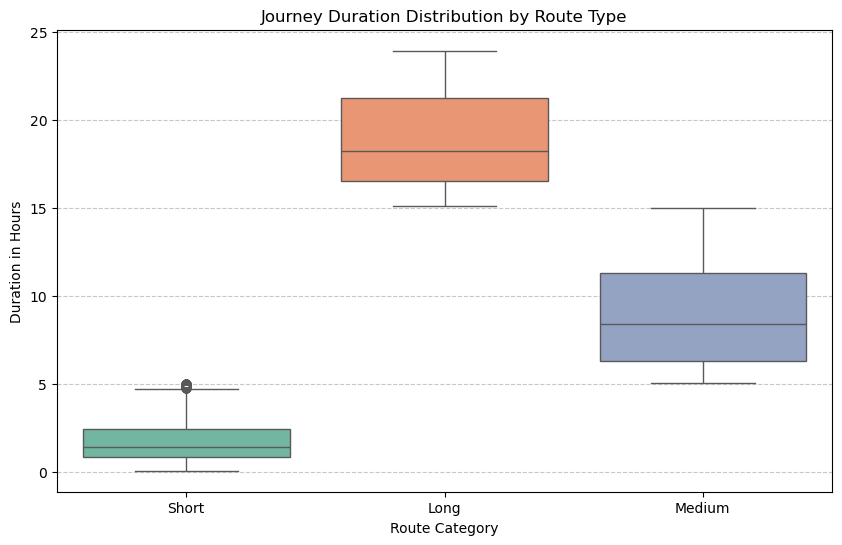

In [30]:
#Level 4: Basic Analysis and Visualization
# Description: Analyze journey durations and station traffic and create simple visual representations.
# Task 4.1: Compare average journey durations across route types
# Task 4.1: Journey Duration Comparison across Route Types
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'duration_df' not in locals():
    start_info = df[df['SN'] == 1][['Train_No', 'Departure_Time', 'Distance']]
    start_info.columns = ['Train_No', 'Start_Time', 'Start_Dist']
    end_idx = df.groupby('Train_No')['SN'].idxmax()
    end_info = df.loc[end_idx, ['Train_No', 'Arrival_time', 'Distance']]
    end_info.columns = ['Train_No', 'End_Time', 'End_Dist']
    duration_df = pd.merge(start_info, end_info, on='Train_No')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Route_Type', y='Duration_Hours', data=duration_df, palette='Set2', hue='Route_Type', legend=False)
plt.title('Journey Duration Distribution by Route Type')
plt.xlabel('Route Category')
plt.ylabel('Duration in Hours')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

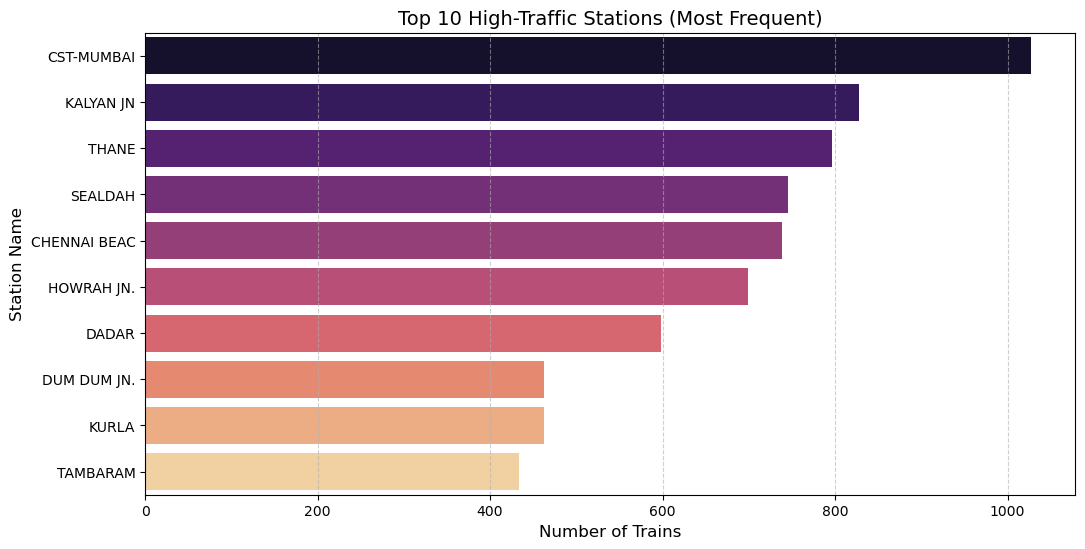

In [31]:
#Task 4.2: Identify high-traffic stations

import matplotlib.pyplot as plt
import seaborn as sns

top_stations = station_frequency.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Train_Count', y='Station_Name', data=top_stations, palette='magma', hue='Station_Name', legend=False)

plt.title('Top 10 High-Traffic Stations (Most Frequent)', fontsize=14)
plt.xlabel('Number of Trains', fontsize=12)
plt.ylabel('Station Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

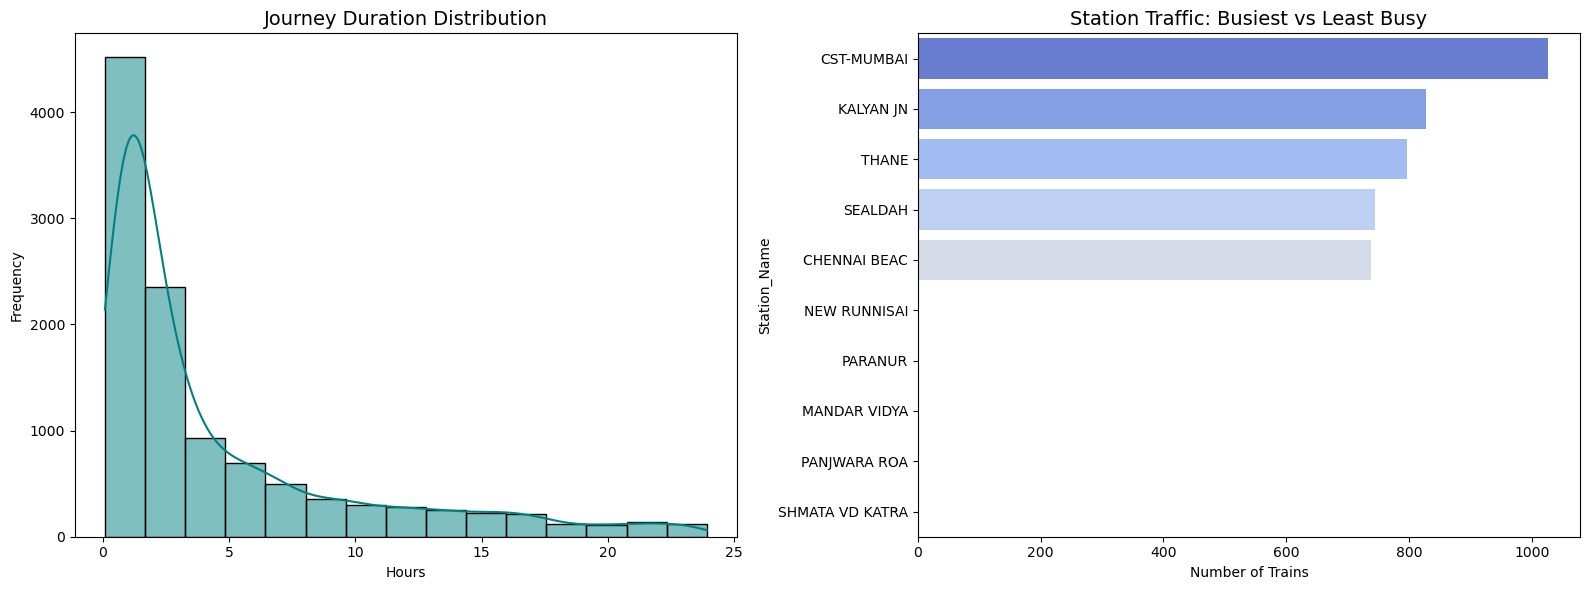

In [32]:
# Task 4.3: Create basic visualizations for journey duration and station traffic

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

# 1. Distribution of Journey Durations
plt.subplot(1, 2, 1)
sns.histplot(duration_df['Duration_Hours'], bins=15, kde=True, color='teal')
plt.title('Journey Duration Distribution', fontsize=14)
plt.xlabel('Hours')
plt.ylabel('Frequency')

# 2. Station Traffic - Top 5 vs Bottom 5
plt.subplot(1, 2, 2)
combined_traffic = pd.concat([station_frequency.head(5), station_frequency.tail(5)])
sns.barplot(x='Train_Count', y='Station_Name', data=combined_traffic, palette='coolwarm', hue='Station_Name', legend=False)
plt.title('Station Traffic: Busiest vs Least Busy', fontsize=14)
plt.xlabel('Number of Trains')

plt.tight_layout()
plt.show()

In [33]:
# Level 5: Advanced Analysis and Visualization

# Description: Conduct in-depth analysis using pivot tables and cross-tabulations to uncover detailed trends.
# Task 5.1: Pivot tables for station-wise train distribution

import pandas as pd

pivot_analysis = duration_df.pivot_table(
    index='Route_Type', 
    values=['Average_Speed_Kmph', 'End_Dist'], 
    aggfunc='mean'
).round(2)

print("--- Pivot Table: Route-wise Performance Summary ---")
print(pivot_analysis)

--- Pivot Table: Route-wise Performance Summary ---
            Average_Speed_Kmph  End_Dist
Route_Type                              
Long                     68.57   1294.34
Medium                   82.22    718.11
Short                   113.62    132.70


In [34]:
# Task 5.2: Cross-tabulations to analyze train frequency between stations and routes
# Identifying top stations for cross-tab analysis
top_10_stations = station_frequency['Station_Name'].head(10).tolist()

station_route_data = pd.merge(df[df['Station_Name'].isin(top_10_stations)], duration_df[['Train_No', 'Route_Type']], on='Train_No')

ctab = pd.crosstab(station_route_data['Station_Name'], station_route_data['Route_Type'])

print("\n--- Cross-tabulation: Station vs Route Type ---")
print(ctab)


--- Cross-tabulation: Station vs Route Type ---
Route_Type    Long  Medium  Short
Station_Name                     
CHENNAI BEAC     0       0    738
CST-MUMBAI      21      55    951
DADAR           40      74    484
DUM DUM JN.      2      13    448
HOWRAH JN.      55     141    503
KALYAN JN       70     126    631
KURLA            0       0    462
SEALDAH         22      31    692
TAMBARAM        19      45    370
THANE           33      92    671


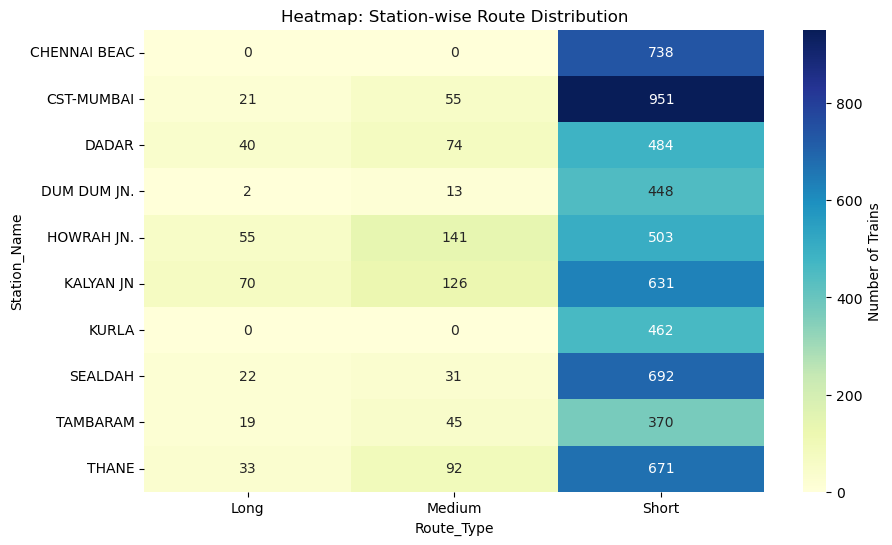

In [35]:
#Task 5.3: Visualizing the Pivot Table (Heatmap)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(ctab, annot=True, cmap="YlGnBu", fmt='d', cbar_kws={'label': 'Number of Trains'})
plt.title('Heatmap: Station-wise Route Distribution')
plt.show()

In [ ]:
# Level6: Final CapstoneSystem
# Description: Build an interactive train enquiry systemfor real-timerouteinformation.
# Task6.1:Interactiveroute-based trainenquiry systemto display:
# All available direct trains between a sourceand destination Estimated journey duration

def find_trains_between_stations():
    print("--- DIRECT TRAIN FINDER ---")
    source = input("Enter Source Station Name (e.g., MADGOAN JN.): ").strip().upper()
    destination = input("Enter Destination Station Name (e.g., SAWANTWADI R): ").strip().upper()
    
    # Filtering trains that pass through the source
    source_trains = df[df['Station_Name'] == source][['Train_No', 'Departure_Time', 'Distance']]
    # Filtering trains that pass through the destination
    dest_trains = df[df['Station_Name'] == destination][['Train_No', 'Arrival_time', 'Distance']]
    
    # Merging to find trains that hit both stations
    matches = pd.merge(source_trains, dest_trains, on='Train_No', suffixes=('_src', '_dest'))
    
    # Logic: Source distance must be less than Destination distance (to ensure correct direction)
    direct_trains = matches[matches['Distance_src'] < matches['Distance_dest']].copy()
    
    if not direct_trains.empty:
        print(f"\nFound {len(direct_trains)} direct trains between {source} and {destination}:")
        
        # Calculate journey duration for the specific segment
        def calc_segment_duration(row):
            dep = pd.to_datetime(row['Departure_Time'], format='%H:%M:%S')
            arr = pd.to_datetime(row['Arrival_time'], format='%H:%M:%S')
            diff = (arr - dep).total_seconds() / 3600
            return round(diff + 24 if diff < 0 else diff, 2)

        direct_trains['Travel_Time_Hrs'] = direct_trains.apply(calc_segment_duration, axis=1)
        
        print("-" * 60)
        print(direct_trains[['Train_No', 'Departure_Time', 'Arrival_time', 'Travel_Time_Hrs']].to_string(index=False))
        print("-" * 60)
    else:
        print(f"\nSorry macha, {source}-la irundhu {destination}-ku direct trains yedhum illai.")

# Run the Finder
find_trains_between_stations()

--- DIRECT TRAIN FINDER ---


Enter Source Station Name (e.g., MADGOAN JN.):  MADGOAN JN
